## Goal and how to run

Download the complete `.ipynb`. In VibeIt Studio's file browser use **+ → Import from Files**, then open it. Run code cells from top to bottom. Saved charts show actual executed results; rerunning recomputes them from embedded data.

This lesson assumes basic Python knowledge. Read each method and caption before changing parameters. AI exercises are optional; no AI account is needed for the core workflow. Data lives in notebook metadata, so there is no companion data download. Keep the notebook saved in the active working folder.

Your goal is to understand the research question, execute transparent calculations, check the results, and state the limits of the conclusion.

## Setup and parameters

In [1]:
from pathlib import Path
import base64, gzip, hashlib, json, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML
import re
from collections import Counter
from IPython.display import display as _display
def display(value):
    if isinstance(value,pd.DataFrame):
        table=value.to_html(max_rows=12,escape=True)
        style="<style>.vibeit-readable-table{max-width:100%;overflow-x:auto}.vibeit-readable-table table{width:max-content;max-width:none;border-collapse:collapse}.vibeit-readable-table td,.vibeit-readable-table th{white-space:nowrap!important;word-break:normal!important;overflow-wrap:normal!important}</style>"
        return _display(HTML(style+'<div class="vibeit-readable-table">'+table+'</div>'))
    return _display(value)
RECIPE_ID='hu05-text-projection'
OUTPUT_DIR=Path.cwd()/"results"/RECIPE_ID
plt.rcParams.update({"figure.dpi":120,"font.size":10,"axes.spines.top":False,"axes.spines.right":False,
                      "axes.prop_cycle":plt.cycler(color=["#18785f","#416aa6","#bc6541","#9974a5"])})
print("Python:",platform.python_version(),"; NumPy:",np.__version__,"; Pandas:",pd.__version__)
print("Working folder:",Path.cwd())
print("Core data mode: embedded snapshot; no network requests")


Python: 3.13.13 ; NumPy: 2.5.3 ; Pandas: 3.0.6
Working folder: /Users/zhiluo/Developer/vibeit-cookbook/cookbook/downloads
Core data mode: embedded snapshot; no network requests


### Load the embedded snapshot

The loader locates this notebook in the working folder by recipe ID and SHA-256, then decompresses and verifies the data. Renaming the file does not change its identity. If loading fails, check the working folder and saved file. Metadata travels with `.ipynb` save/export; copying code to a standalone `.py` does not copy the dataset.

In [2]:
def load_snapshot(recipe_id, expected_sha256, snapshot_key):
    """Read embedded data from this notebook, including a renamed copy."""
    for path in sorted(Path.cwd().glob("*.ipynb")):
        try:
            notebook = json.loads(path.read_text(encoding="utf-8"))
            metadata = notebook.get("metadata", {}).get("vibeit_cookbook", {})
            blob = metadata.get("snapshots", {}).get(snapshot_key)
            if metadata.get("recipe_id") != recipe_id or not blob:
                continue
            if blob.get("sha256") != expected_sha256:
                continue
            raw = gzip.decompress(base64.b64decode(blob["gzip_base64"], validate=True))
            if hashlib.sha256(raw).hexdigest() != expected_sha256:
                raise ValueError("Embedded snapshot checksum mismatch: " + snapshot_key)
            return json.loads(raw)
        except (OSError, json.JSONDecodeError):
            continue
    raise FileNotFoundError(
        "Save/open the complete .ipynb in the active working folder. "
        "The embedded snapshot could not be located for " + recipe_id)

SNAPSHOT_HASHES={'novels': 'c03763abb21b2380d2934b088f1c22a6d5a4675b17e23534e3f7343dc90084ec'}
def snapshot(key):
    return load_snapshot(RECIPE_ID,SNAPSHOT_HASHES[key],key)
print("Embedded snapshots:",list(SNAPSHOT_HASHES))


Embedded snapshots: ['novels']


### Read the method functions

The full implementations appear below. They use the listed bundled packages and standard library; no cookbook helper module is imported at runtime. Inspect input requirements and return values. If you change an algorithm, its checks must still pass.

In [3]:
def strip_ebook_wrapper(raw_text):
    """Return the analysis body while the unmodified source/complete license remain in metadata."""
    text=raw_text.replace('\r\n','\n').replace('\r','\n')
    start=re.search(r'\*\*\* START[^\n]*\*\*\*',text,re.I)
    end=re.search(r'\*\*\* END[^\n]*\*\*\*',text,re.I)
    if not start or not end or end.start()<=start.end():raise ValueError('Ebook start/end markers not found')
    return text[start.end():end.start()]

print("Method ready: strip_ebook_wrapper")


Method ready: strip_ebook_wrapper


In [4]:
def split_novel_chapters(body):
    """Declared two-ebook rule: repeated labels resolve to last heading, excluding their TOCs."""
    headings=list(re.finditer(r'(?im)^\s*chapter\s+([ivxlcdm]+|\d+)[.\]]*\s*$',body))
    if not headings:raise ValueError('No supported chapter headings')
    last={match.group(1).upper():match for match in headings}
    chosen=sorted(last.values(),key=lambda match:match.start());chapters=[]
    for j,match in enumerate(chosen):
        text=body[match.end():chosen[j+1].start() if j+1<len(chosen) else len(body)]
        text=re.sub(r'\[Illustration\b[^\]]*\]',' ',text,flags=re.I|re.S)
        text=text.replace('_','').replace('’',"'").strip()
        if len(text)<300:raise ValueError('Unexpected short chapter after declared TOC rule')
        chapters.append(dict(label=match.group(1).upper(),order=j+1,text=text))
    return chapters

print("Method ready: split_novel_chapters")


Method ready: split_novel_chapters


In [5]:
def tokenize_words(text):
    """Transparent English-letter tokenizer; punctuation/case decisions are part of the method."""
    return re.findall(r"[a-z]+(?:'[a-z]+)?",text.lower().replace('’',"'"))

print("Method ready: tokenize_words")


Method ready: tokenize_words


In [6]:
def tfidf_svd(documents,stopwords,min_df=3,max_df_fraction=.9,max_terms=500,components=3):
    """Exploratory TF-IDF + uncentered SVD; signed components are not topic probabilities."""
    if len(documents)<3 or components<1 or max_terms<2:raise ValueError('Need documents and valid model sizes')
    counts=[Counter(word for word in tokenize_words(text) if word not in stopwords) for text in documents]
    frequency=Counter();totals=Counter()
    for count in counts:frequency.update(count.keys());totals.update(count)
    eligible=[word for word in frequency if min_df<=frequency[word]<=max_df_fraction*len(documents)]
    terms=sorted(eligible,key=lambda word:(-totals[word],word))[:max_terms]
    if len(terms)<components:raise ValueError('Vocabulary too small for the requested components')
    matrix=np.array([[count.get(word,0) for word in terms] for count in counts],dtype=float)
    idf=np.log((1+len(documents))/(1+np.count_nonzero(matrix,axis=0)))+1
    matrix*=idf
    norms=np.linalg.norm(matrix,axis=1)
    if np.any(norms==0):raise ValueError('A document has no retained terms')
    matrix/=norms[:,None]
    left,singular,right=np.linalg.svd(matrix,full_matrices=False)
    for j in range(min(components,len(singular))):
        if right[j,np.argmax(abs(right[j]))]<0:right[j]*=-1;left[:,j]*=-1
    return dict(terms=terms,tfidf=matrix,idf=idf,scores=left[:,:components]*singular[:components],components=right[:components],singular_values=singular)

print("Method ready: tfidf_svd")


Method ready: tfidf_svd


### Data and model boundary

The snapshot retains complete unmodified source ebooks, including their original licenses. Chapter-based analysis uses 61 Pride and Prejudice chapters and 24 Frankenstein chapters; front matter and Frankenstein framing letters are outside this declared scope. English-letter tokenization is a method choice, not a language-neutral definition. Word frequencies, surface-pattern cooccurrence and SVD axes do not independently establish authorial intent, character relationships or sentiment.

## Steps

### 1. Define chapters and vocabulary rules

Use 85 numbered chapters as exploratory documents. A declared short stop list, document-frequency limits and a 500-term cap define the representation. This analysis uses the full corpus and is not a held-out classifier.

In [7]:
novels=snapshot("novels");corpus={};chapter_rows=[]
for book in novels["books"]:
 chapters=split_novel_chapters(strip_ebook_wrapper(book["raw_text"]))
 tokens=tokenize_words(" ".join(chapter["text"] for chapter in chapters))
 corpus[book["id"]]={"title":book["title"],"author":book["author"],"chapters":chapters,"tokens":tokens}
 for chapter in chapters:chapter_rows.append({"book_id":book["id"],"book":book["title"],"chapter":chapter["order"],"source_label":chapter["label"],"characters":len(chapter["text"]),"tokens":len(tokenize_words(chapter["text"])),"text":chapter["text"]})
chapter_table=pd.DataFrame(chapter_rows)
assert len(corpus[1342]["chapters"])==61 and len(corpus[84]["chapters"])==24
print(novels["source_notice"])
print("Declared chapter counts:",{b:len(corpus[b]["chapters"]) for b in corpus})
display(chapter_table.drop(columns="text").head(8))
stopwords=set("a an and are as at be been being but by can could did do does for from had has have he her hers him his i if in is it its me more most my no not of on one or our she so some than that the their them then there these they this those to too was we were what when where which who why will with would you your".split())
documents=chapter_table.text.tolist();model=tfidf_svd(documents,stopwords,min_df=3,max_df_fraction=.9,max_terms=500,components=3)
print("Documents:",len(documents),"; retained terms:",len(model["terms"]),"; TF-IDF row normalization: L2")


These source ebooks are available free of charge. Complete unmodified source texts and their licenses are included in this snapshot. Project Gutenberg is acknowledged as the transcription source; its name is not used as a course title or endorsement.
Declared chapter counts: {1342: 61, 84: 24}


,book_id,book,chapter,source_label,characters,tokens
0,1342,Pride and Prejudice,1,I,4490,853
1,1342,Pride and Prejudice,2,II,4293,799
2,1342,Pride and Prejudice,3,III,9560,1704
3,1342,Pride and Prejudice,4,IV,5931,1064
4,1342,Pride and Prejudice,5,V,5246,962
5,1342,Pride and Prejudice,6,VI,13023,2353
6,1342,Pride and Prejudice,7,VII,11263,2000
7,1342,Pride and Prejudice,8,VIII,10993,1936


Documents: 85 ; retained terms: 500 ; TF-IDF row normalization: L2


### 2. Read signed word directions

TF-IDF uses smoothed idf=log((1+n)/(1+df))+1 and L2 document normalization. SVD is uncentered. Each component has signed coefficients with an arbitrary global sign; it is not a probability distribution of topics.

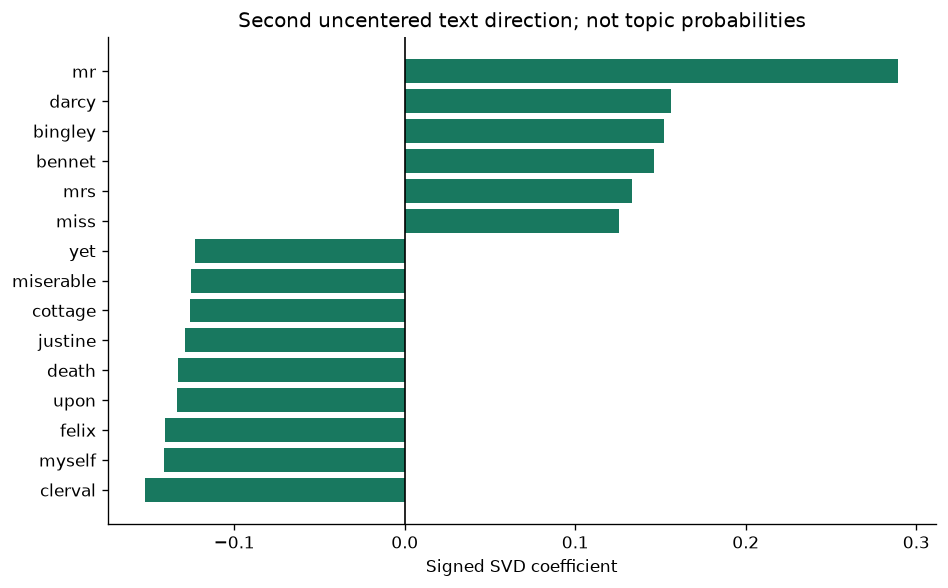

In [8]:
component=1;loading=model["components"][component]
selected=np.argsort(abs(loading))[-15:];selected=selected[np.argsort(loading[selected])]
fig,ax=plt.subplots(figsize=(8,5));ax.barh([model["terms"][j] for j in selected],loading[selected])
ax.axvline(0,color="black",lw=1);ax.set(xlabel="Signed SVD coefficient",title="Second uncentered text direction; not topic probabilities");plt.tight_layout();plt.show()


### 3. Inspect chapter projection geometry

Points are chapter documents; colors show source book identity. Geometry depends on vocabulary, normalization and truncation. Source-book separation does not establish author intention or a validated genre classifier.

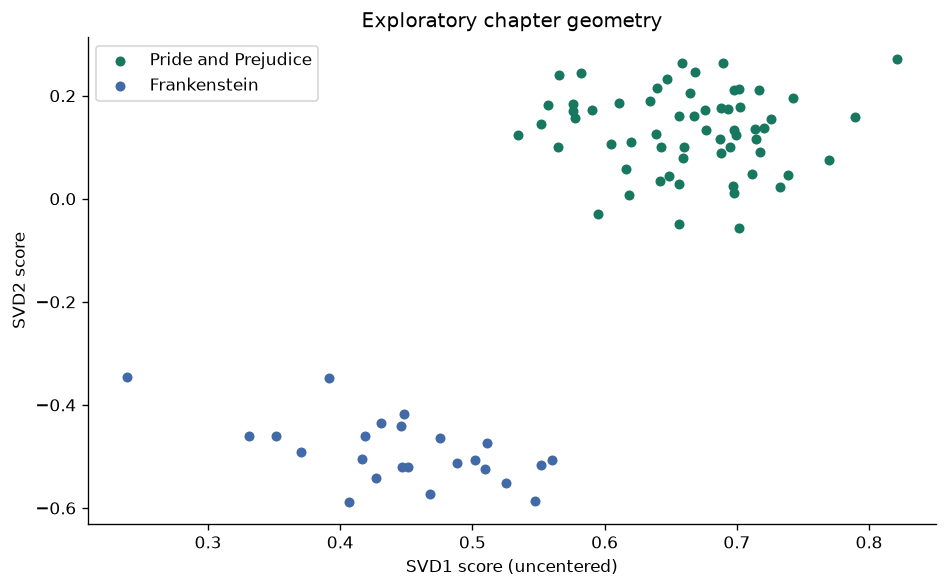

In [9]:
fig,ax=plt.subplots(figsize=(8,5))
for book_id in corpus:
 mask=chapter_table.book_id.eq(book_id).to_numpy();ax.scatter(model["scores"][mask,0],model["scores"][mask,1],label=corpus[book_id]["title"],s=25)
ax.set(xlabel="SVD1 score (uncentered)",ylabel="SVD2 score",title="Exploratory chapter geometry");ax.legend();plt.tight_layout();plt.show()


### 4. Read cosine similarity in the original TF-IDF space

Because rows are L2 normalized, their dot product gives original-space cosine similarity. This matrix concerns a declared bag-of-words representation, not identity of meaning, events or characters.

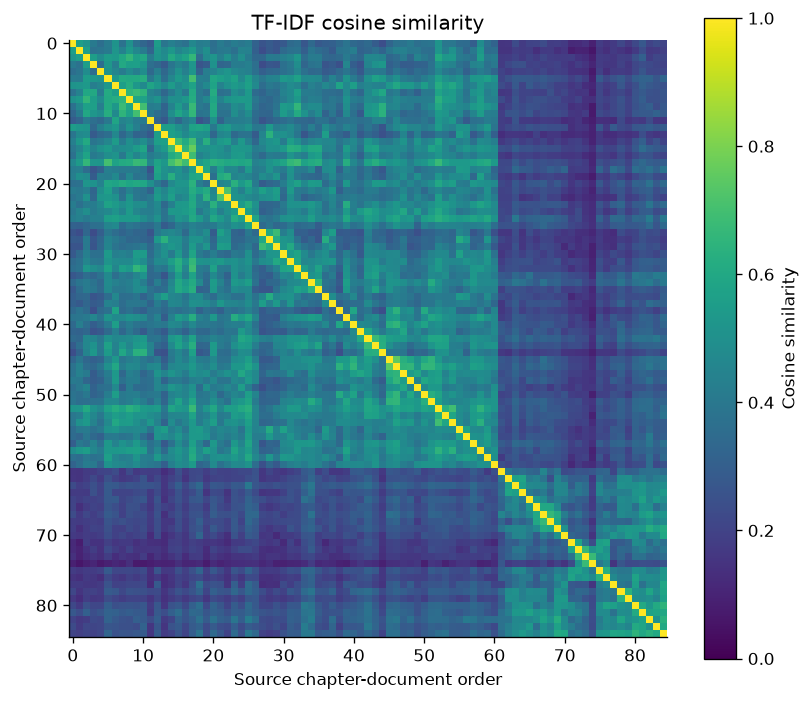

In [10]:
similarity=model["tfidf"]@model["tfidf"].T
fig,ax=plt.subplots(figsize=(7,6));im=ax.imshow(similarity,vmin=0,vmax=1,cmap="viridis")
ax.set(xlabel="Source chapter-document order",ylabel="Source chapter-document order",title="TF-IDF cosine similarity");fig.colorbar(im,ax=ax,label="Cosine similarity");plt.tight_layout();plt.show()


### 5. Reconcile normalization and export representation

Check unit row norms, symmetric similarity and orthonormal retained directions. Export vocabulary and signed weights so a student can inspect influential terms and return to the original passages.

In [11]:
assert np.allclose(np.linalg.norm(model["tfidf"],axis=1),1)
assert np.allclose(similarity,similarity.T) and np.allclose(np.diag(similarity),1)
assert np.allclose(model["components"]@model["components"].T,np.eye(3))
OUTPUT_DIR.mkdir(parents=True,exist_ok=True)
pd.DataFrame(model["scores"],columns=["SVD1","SVD2","SVD3"]).assign(book=chapter_table.book,chapter=chapter_table.chapter).to_csv(OUTPUT_DIR/"chapter-projections.csv",index=False)
pd.DataFrame(model["components"].T,index=model["terms"],columns=["SVD1","SVD2","SVD3"]).to_csv(OUTPUT_DIR/"signed-term-directions.csv")
print("Normalization and orthogonality checked; exports:",OUTPUT_DIR)


Normalization and orthogonality checked; exports: /Users/zhiluo/Developer/vibeit-cookbook/cookbook/downloads/results/hu05-text-projection


## Exercises and reference explanation

1. Why are signed SVD directions not topic probabilities?
2. How do vocabulary/normalization decisions change geometry?

**Reference explanation.** SVD components are signed linear directions with arbitrary global sign. Selected terms and weighting define the representation, not a universal semantic model.

Keep a copy before changing parameters. Compare old and new figures and record which inputs, calculations and conclusions changed.

## Optional AI coding exercises

Open the current notebook in VibeIt's Coding Agent and ask it to read the relevant cells. The core lesson does not depend on AI access; see the Help Center for provider and account setup.

**Prompt 1**

> Using re/Counter/NumPy/Pandas/Matplotlib, compare 300 and 500 retained terms and preserve representation parameters.

**Prompt 2**

> With the same packages, export both positive and negative influential terms and inspect their source chapters.

**Human acceptance.** Rows have unit L2 norm, components are orthonormal, similarity is symmetric and no topic-probability claim is made.

Review the edited source, then manually run affected cells and subsequent checks. Ask the assistant to explain the purpose, packages and data provenance of its changes, and reconcile that explanation with actual output.

## Optional online extension

The network action below is disabled by default. It reports a database version/source without replacing the core data. To refresh data, save a separate experimental version and record the new URL, database release, retrieval date and SHA-256. New results require rerunning and validation.

In [12]:
RUN_ONLINE_UPDATE=False
if RUN_ONLINE_UPDATE:
    import requests
    try:
        response=requests.get('https://www.gutenberg.org/ebooks/1342',timeout=20)
        response.raise_for_status()
        print("Source:",response.url)
        print(response.text[:700])
    except requests.RequestException as error:
        print("Online extension unavailable:",type(error).__name__,str(error)[:160])
else:
    print("Online extension skipped; embedded core data unchanged")


Online extension skipped; embedded core data unchanged


## Sources, snapshots and next steps

- [Historical novel 1342](https://www.gutenberg.org/cache/epub/1342/pg1342.txt) — Original novel public domain in USA; complete source ebook and its Project Gutenberg license retained; free distribution and acknowledgment links; retrieved 2026-10-09. SHA-256 `3f6bb9d6f78e0293b56acd4714dd68cb7d6d1d293402031ce9d5a216bcaf9d75`.
  Preserve unmodified UTF-8 source including ebook headers and complete license; preprocessing occurs visibly in the notebook.

- [Historical novel 84](https://www.gutenberg.org/cache/epub/84/pg84.txt) — Original novel public domain in USA; complete source ebook and its Project Gutenberg license retained; free distribution and acknowledgment links; retrieved 2026-10-09. SHA-256 `7810cd483cffcf2cc8a1d8f0d5807931e69d4f48cd14149b8c76f88af82fead3`.
  Preserve unmodified UTF-8 source including ebook headers and complete license; preprocessing occurs visibly in the notebook.


**Next steps.** Transfer these methods to your own public or authorized data while retaining input checks, recorded parameters and result validation. Document the new experimental design and method limits; this example does not validate a new experiment. Full data licenses and generation instructions accompany the cookbook.